In [6]:
URL = ("https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst")

In [7]:
import pandas as pd
df = pd.read_csv(URL)

In [8]:
df

,mmsi,base_date_time,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
0,367793030,2025-01-08 00:00:00,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
1,338160209,2025-01-08 00:00:00,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2,266283000,2025-01-08 00:00:01,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
3,368013620,2025-01-08 00:00:10,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
4,368144150,2025-01-08 00:00:09,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5929626,368920000,2025-01-08 18:58:42,144.66472,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
5929627,368920000,2025-01-08 19:49:42,144.66471,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
5929628,368920000,2025-01-08 21:13:42,144.66474,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A
5929629,368920000,2025-01-08 22:07:42,144.66475,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A


In [9]:
# Set the index to the base_date_time. Your index should be a DateTimeIndex
# firstly we can view the index
df.index

RangeIndex(start=0, stop=5929631, step=1)

In [10]:
#setting the index which is not unique
df = df.set_index("base_date_time")

# We can convert our index from a type string to a type datetime
df.index = pd.to_datetime(df.index)

In [11]:
# Clean the data: we don't want any row where the sog is null
df = df.dropna(subset=['sog'])

# Lets check the length of the df after cleaning it
print(len(df))

5917091


<Axes: xlabel='hour', ylabel='mmsi'>

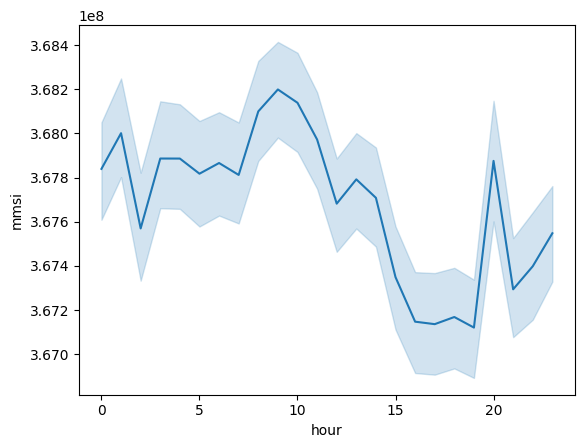

In [12]:
# When are boats out?
#Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour.
# Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water?
# And the least? Does this track with what you could expect?

# Extract hour from date time index
df["hour"] = df.index.hour

# Counting the number of vessels per hour
vessels_per_hour = df.groupby('hour')["mmsi"].nunique()

# Plotting the line graph
import seaborn as sns
sns.lineplot(df.loc["2025"], x="hour",y="mmsi")

In [13]:
# Henry Hudson (MMSI: 366651000)

# Filter data for the specific boat
henry_hudson = df[df['mmsi'] == 366651000].copy()

# Make sure the data is sorted by time (important for diff())
henry_hudson = henry_hudson.sort_index()

print("Number of records for Henry Hudson:", len(henry_hudson))
df

Number of records for Henry Hudson: 686


,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,hour
base_date_time,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,367793030,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B,0
2025-01-08 00:00:00,338160209,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B,0
2025-01-08 00:00:01,266283000,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A,0
2025-01-08 00:00:10,368013620,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B,0
2025-01-08 00:00:09,368144150,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-08 18:58:42,368920000,144.66472,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A,18
2025-01-08 19:49:42,368920000,144.66471,13.42224,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A,19
2025-01-08 21:13:42,368920000,144.66474,13.42225,0.0,NaN,149.0,HENSON,IMO9132129,NENB,35.0,5.0,100.0,18.0,NaN,35.0,A,21


In [29]:
# a) Create acceleration column (difference in speed)
df["acceleration"] = df["sog"].diff()

# b) Create duration column (time difference between consecutive records in minutes)
df['duration'] = henry_hudson.index.to_series().diff().dt.total_seconds() / 60

print(df[['sog', 'acceleration', 'duration']].head(10))

                      sog  acceleration  duration
base_date_time                                   
2025-01-08 00:00:00   4.6           NaN       NaN
2025-01-08 00:00:00   0.0          -4.6       NaN
2025-01-08 00:00:01  15.5          15.5       NaN
2025-01-08 00:00:10   0.0         -15.5       NaN
2025-01-08 00:00:09   0.0           0.0       NaN
2025-01-08 00:00:10   0.0           0.0       NaN
2025-01-08 00:00:19   0.0           0.0       NaN
2025-01-08 00:00:20   0.0           0.0       NaN
2025-01-08 00:00:05   0.1           0.1       NaN
2025-01-08 00:00:04   3.6           3.5       NaN


In [27]:
# Now to calculate engine active time
active_periods = df[df['acceleration'] > 0]

# Add them (active times) all together
total_active_minutes = active_periods['duration'].sum()

# Convert to hours and minutes for easy reading
total_hours = int(total_active_minutes // 60)
total_mins = int(total_active_minutes % 60)

print(f"Total engine active time: {total_active_minutes:.1f} minutes")
print(f"That's approximately {total_hours} hours and {total_mins} minutes")

Total engine active time: 36498.9 minutes
That's approximately 608 hours and 18 minutes
